In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ✅ 한글 폰트 설정 (Mac용)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1) 엑셀 읽기 (프로젝트 루트의 data/Engagement_interaction.xlsx)
df = pd.read_csv(os.path.join('final_customer_data_20260408.csv'))


### SHAP 중요도 TOP 15 ###
                     feature  mean_abs_shap
0              Purchase_Span       0.903893
1             Avg_Unit_Price       0.360974
2     Basket_Diversity_Index       0.291976
3              Revenue_Trend       0.265116
4              Month_Entropy       0.215598
5         New_Category_Ratio       0.197742
6                   Monetary       0.172697
7       Low_Price_Item_Ratio       0.171566
8      High_Price_Item_Ratio       0.163579
9    Country_Trend_Alignment       0.144503
10  Max_Single_Order_Revenue       0.143187
11           Avg_Basket_Size       0.143137
12            Frequency_Pure       0.137265
13            Price_Variance       0.133818
14            Preferred_Hour       0.122645


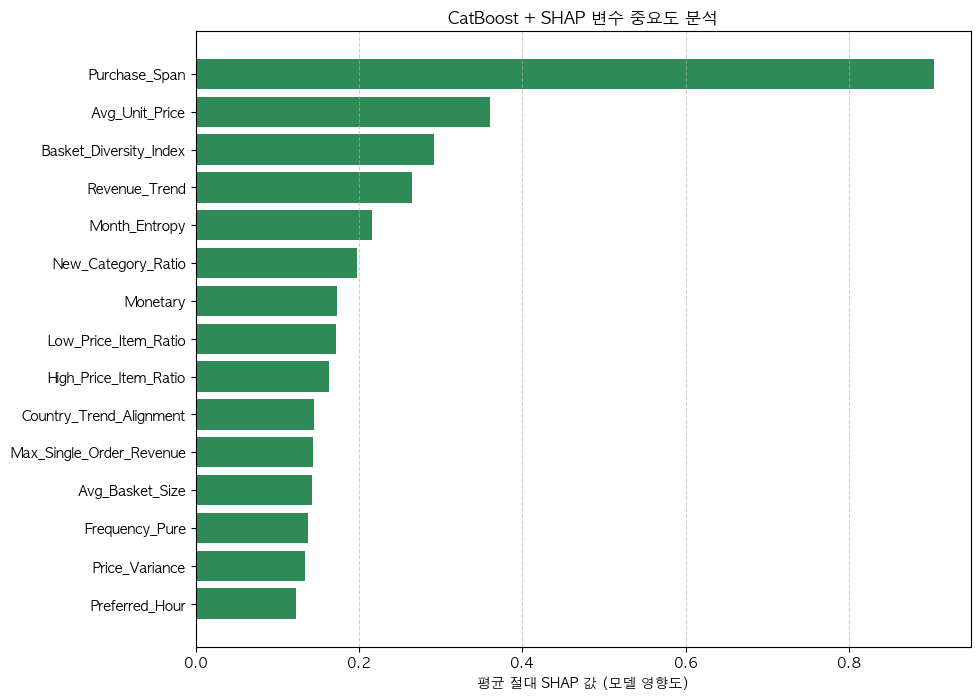

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
import shap

# 2) 분석에서 제외할 컬럼 정의
# - 식별자: CustomerID, index
# - 정보가 없는 상수 변수: Avg_Items_per_Order, Revenue_Consistency
# - Target_Churn 생성의 직접적 원인: Recency
# - 중복 지표: Frequency (Frequency_Pure를 대신 사용)
drop_cols = ['CustomerID', 'index', 'Recency', 'Avg_Items_per_Order', 
             'Revenue_Consistency', 'Frequency']
target_cols = ['Target_Churn', 'Target_Context', 'Target_Budget', 'Target_Impulse']

# 3) 특징(X)과 정답(y) 분리
X = df.drop(columns=drop_cols + target_cols)
y = df['Target_Churn']

# 4) 데이터 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5) 데이터 스케일링 (CatBoost 성능 및 SHAP 비교를 위해 필수)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 데이터프레임 형태 유지 (SHAP 시각화 시 컬럼명 확인을 위함)
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

# 6) CatBoost 모델 학습
model = CatBoostClassifier(
    n_estimators=500, 
    learning_rate=0.1, 
    max_depth=7,
    random_state=42, 
    verbose=0
)
model.fit(X_train_final, y_train)

# 7) SHAP 값 계산
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_test_final)

# CatBoost SHAP 결과는 보통 (샘플수, 변수수)의 2차원 배열로 반환됨
shap_arr_all = shap_vals

# 8) SHAP 절댓값 평균 기준 정렬 (현서님의 로직)
mean_abs_shap = np.mean(np.abs(shap_arr_all), axis=0)
shap_df = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

# 9) 결과 출력 및 시각화
print("\n### SHAP 중요도 TOP 15 ###")
print(shap_df.head(15))

plt.figure(figsize=(10, 8))
plt.barh(shap_df['feature'].head(15)[::-1], shap_df['mean_abs_shap'].head(15)[::-1], color='seagreen')
plt.xlabel('평균 절대 SHAP 값 (모델 영향도)')
plt.title('CatBoost + SHAP 변수 중요도 분석')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

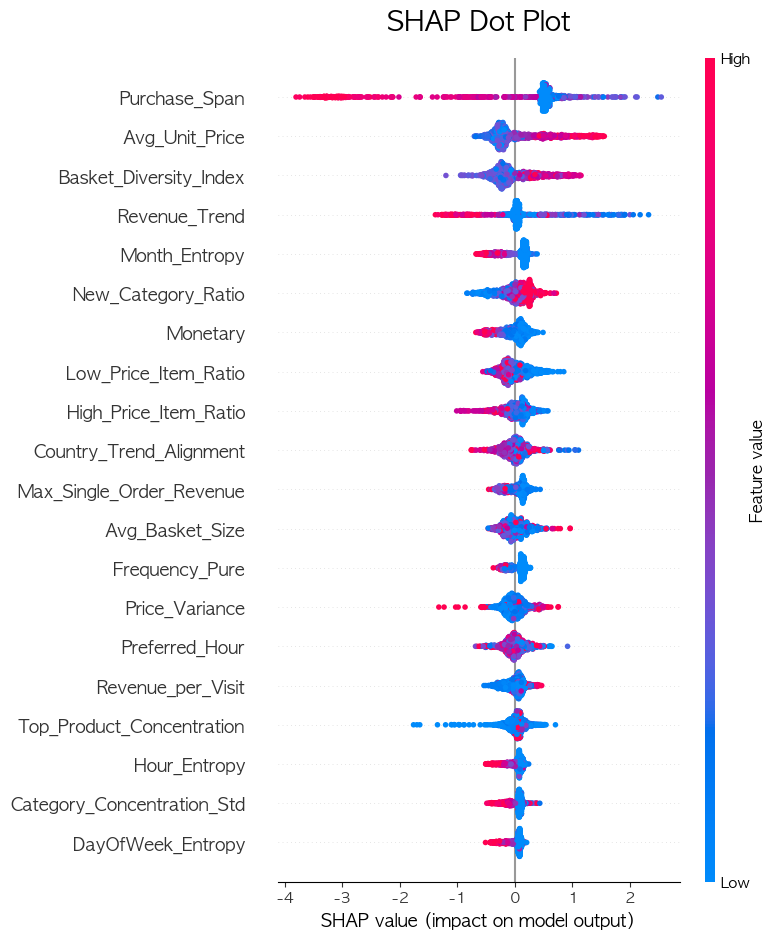

In [8]:
import matplotlib.pyplot as plt

# 10) SHAP Dot Plot (Beeswarm Plot) 시각화
# plot_type="dot"이 기본값이므로, shap_vals와 데이터를 넣어주면 됩니다.
plt.figure(figsize=(10, 8))

# shap_vals: 각 특징의 기여도
# X_test_final: 점의 색상(Feature Value: High/Low)을 결정하기 위한 실제 값 데이터프레임
shap.summary_plot(shap_vals, X_test_final, plot_type="dot", show=False)

# 제목 설정 (이미지와 동일하게)
plt.title("SHAP Dot Plot", fontsize=20, pad=20)

# 레이아웃 정리 및 출력
plt.tight_layout()
plt.show()

### 모델 평가 결과 ###
Accuracy  : 0.7439
Precision : 0.7106
Recall    : 0.7720
F1-Score  : 0.7400
ROC-AUC   : 0.8357
------------------------------


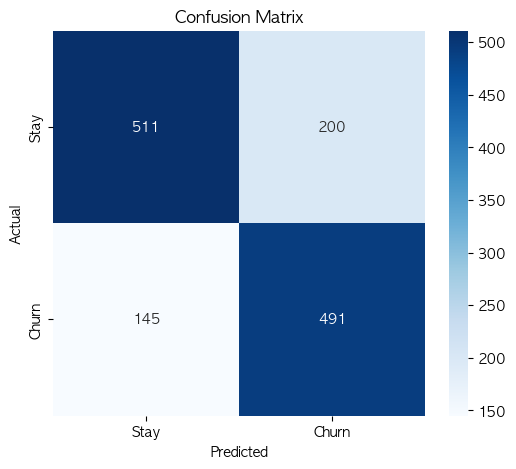


### 상세 분류 리포트 ###
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       711
           1       0.71      0.77      0.74       636

    accuracy                           0.74      1347
   macro avg       0.74      0.75      0.74      1347
weighted avg       0.75      0.74      0.74      1347



In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns

# 1) 예측 수행
y_pred = model.predict(X_test_final)
y_pred_proba = model.predict_proba(X_test_final)[:, 1] # AUC 계산을 위한 확률값

# 2) 주요 지표 계산
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"### 모델 평가 결과 ###")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("-" * 30)

# 3) 혼동 행렬 (Confusion Matrix) 시각화
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stay', 'Churn'], 
            yticklabels=['Stay', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 4) 상세 리포트 출력
print("\n### 상세 분류 리포트 ###")
print(classification_report(y_test, y_pred))